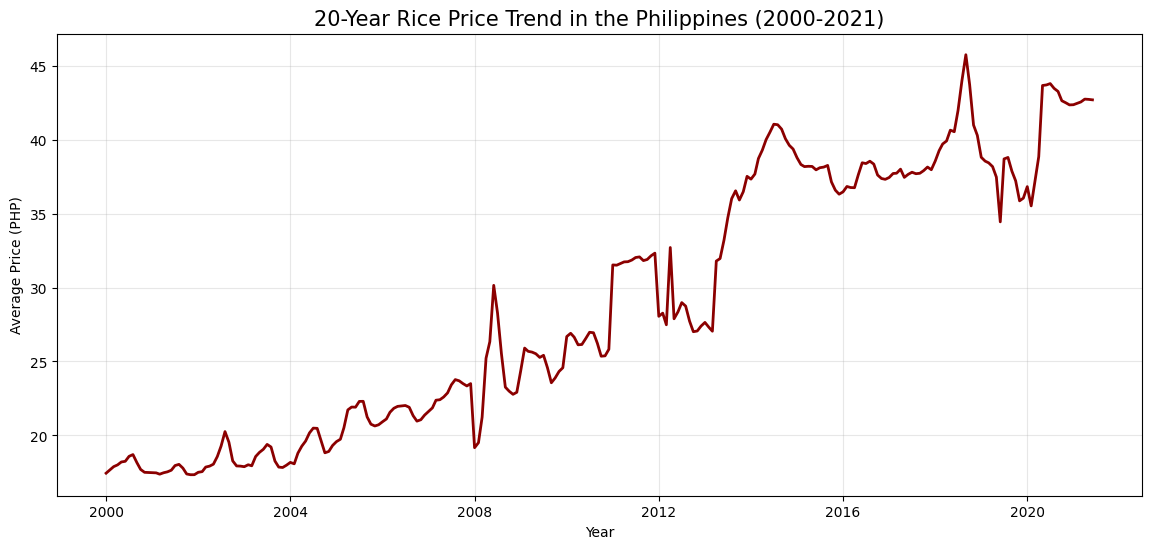

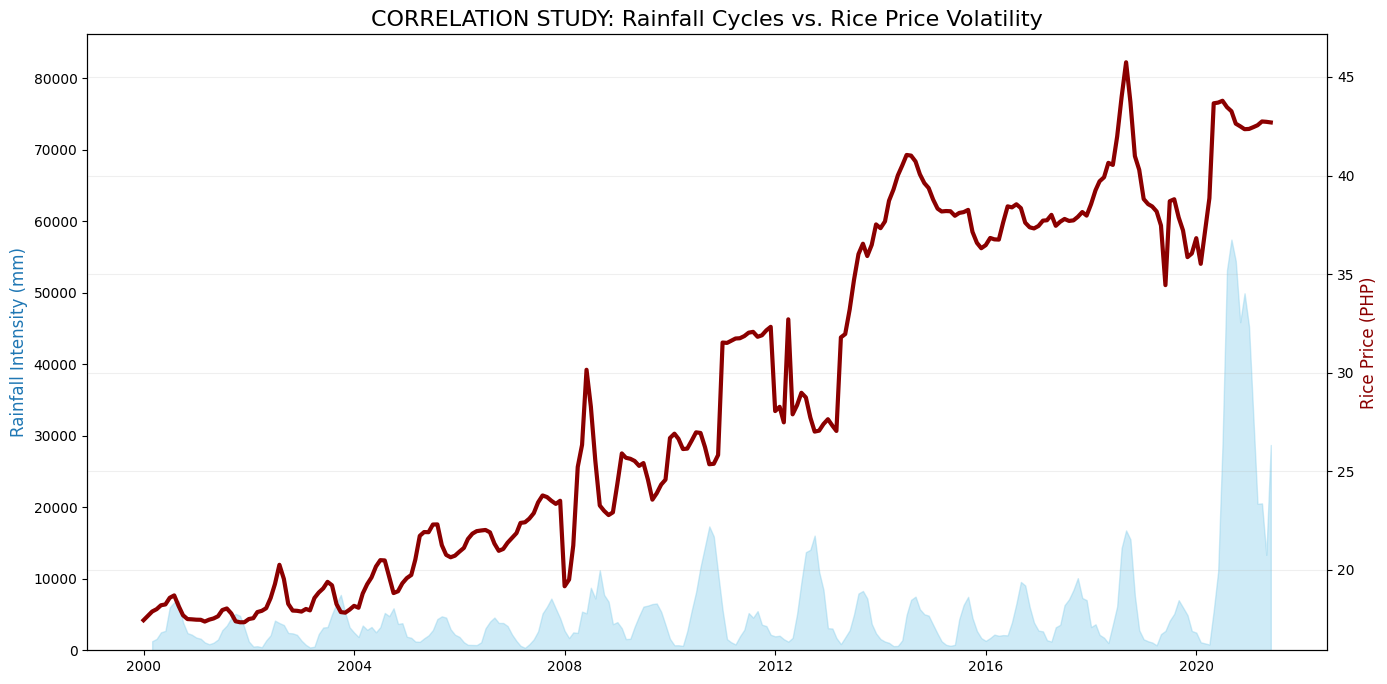

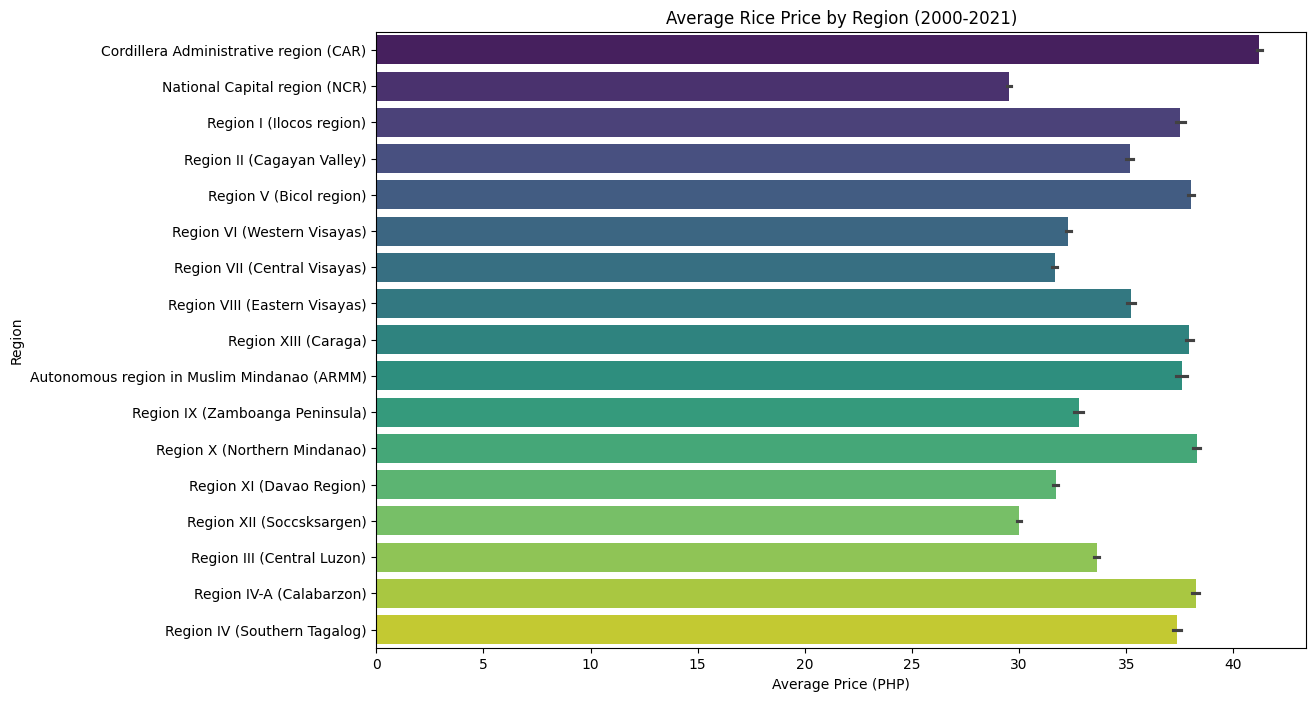

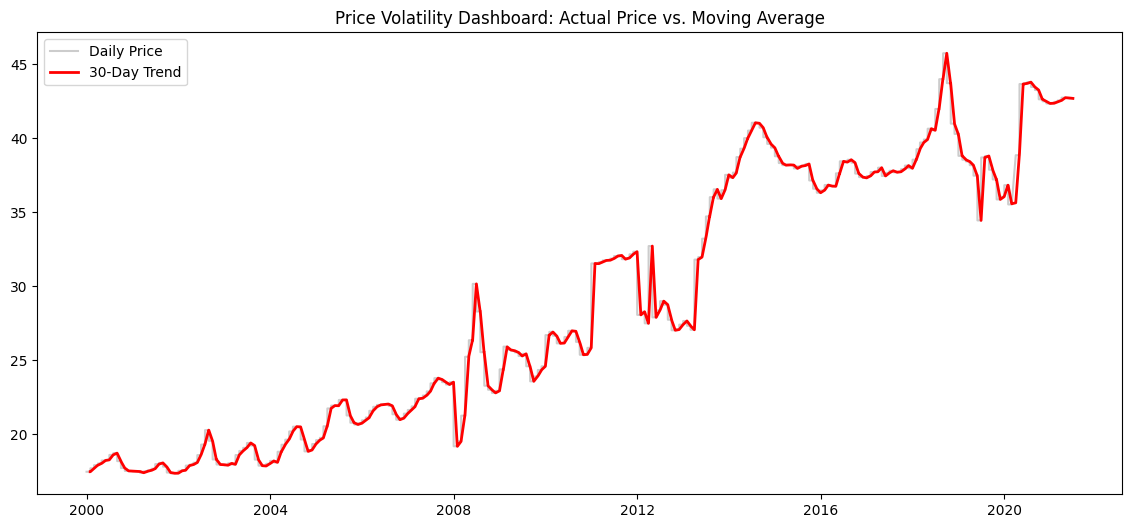

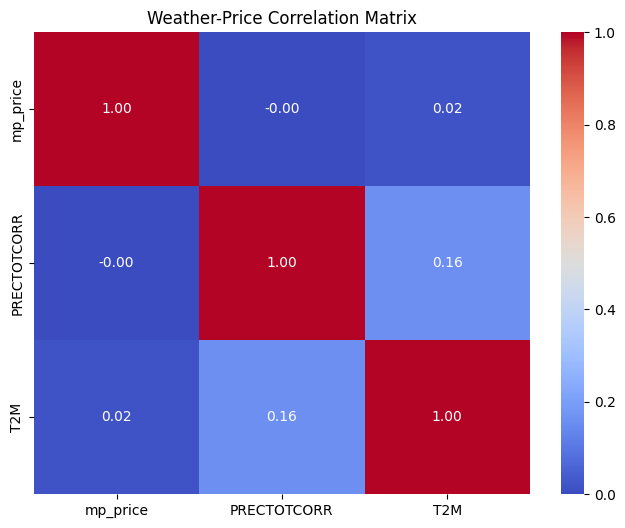

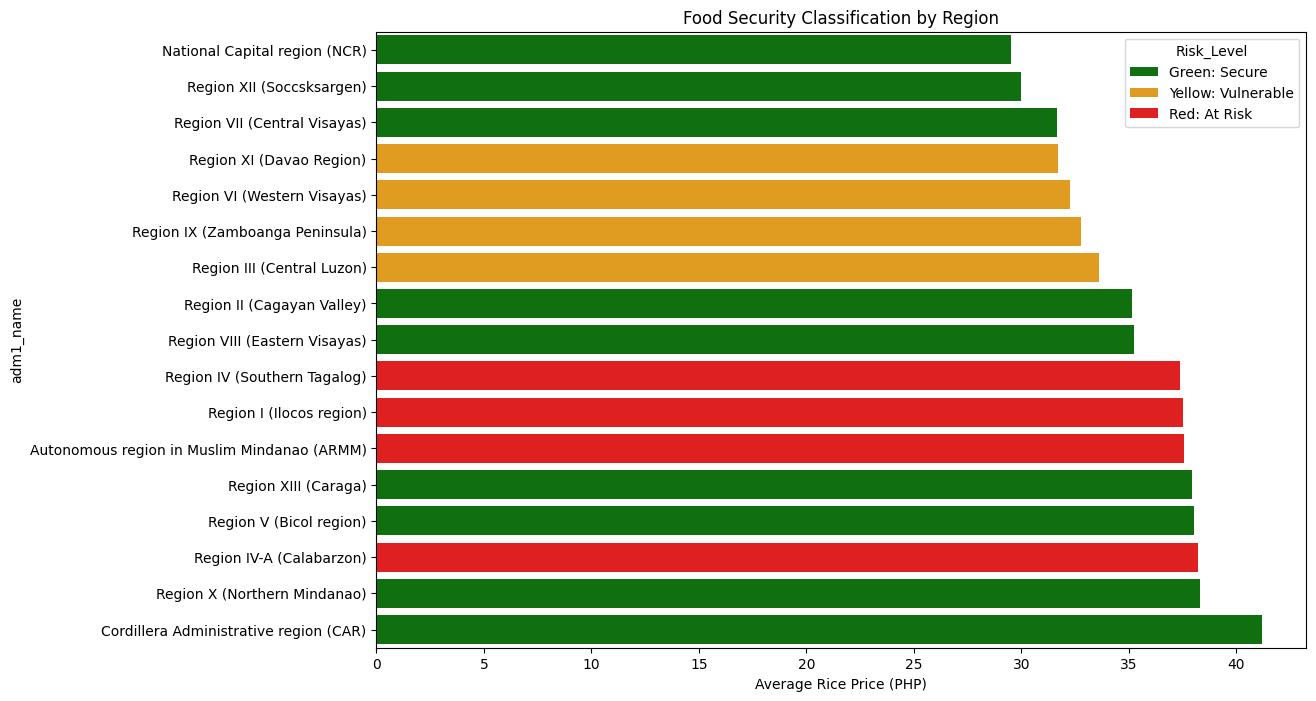

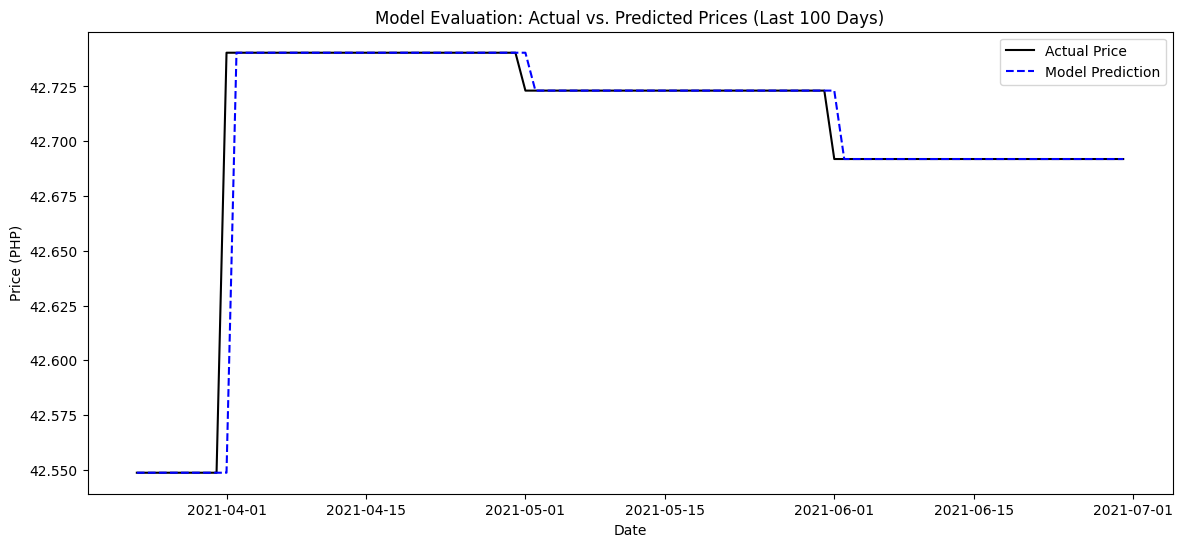

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. SETUP & DATA LOADING ---
# This pathing assumes your script/notebook is inside the 'notebooks' folder.
# '..' goes up one level to the root, then enters 'data/processed'.
root_path = os.getcwd()
file_path = os.path.join(root_path, '..', 'data', 'processed', 'final_master_dataset_fixed.csv')

# Verify file exists before loading to prevent errors
if not os.path.exists(file_path):
    print(f"Error: Could not find the file at {file_path}")
    print("Check if your file is named correctly in the 'data/processed' folder.")
else:
    # Load the master dataset once for all plots
    df = pd.read_csv(file_path, low_memory=False)

    # Pre-processing shared across multiple plots
    df['date'] = pd.to_datetime(df['date'])
    rice_df = df[df['cm_name'].str.contains('Rice', na=False)].copy()

    # --- 2. TIME SERIES: 20-YEAR TREND ---
    plt.figure(figsize=(14, 6))
    trend_df = rice_df.groupby(rice_df['date'].dt.to_period('M'))['mp_price'].mean().reset_index()
    trend_df['date'] = trend_df['date'].dt.to_timestamp()

    sns.lineplot(data=trend_df, x='date', y='mp_price', color='darkred', linewidth=2)
    plt.title('20-Year Rice Price Trend in the Philippines (2000-2021)', fontsize=15)
    plt.ylabel('Average Price (PHP)')
    plt.xlabel('Year')
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 3. CORRELATION STUDY: RAINFALL CYCLES VS VOLATILITY ---
    monthly = rice_df.groupby(rice_df['date'].dt.to_period('M')).agg({
        'mp_price': 'mean',
        'PRECTOTCORR': 'sum'
    }).reset_index()
    monthly['date'] = monthly['date'].dt.to_timestamp()
    monthly['Rain_Smooth'] = monthly['PRECTOTCORR'].rolling(window=3).mean()

    fig, ax1 = plt.subplots(figsize=(16, 8))
    ax1.fill_between(monthly['date'], monthly['Rain_Smooth'], color='skyblue', alpha=0.4, label='Rainfall Trend')
    ax1.set_ylabel('Rainfall Intensity (mm)', color='tab:blue', fontsize=12)
    ax1.set_ylim(0, monthly['Rain_Smooth'].max() * 1.5)

    ax2 = ax1.twinx()
    ax2.plot(monthly['date'], monthly['mp_price'], color='darkred', linewidth=3, label='Rice Price')
    ax2.set_ylabel('Rice Price (PHP)', color='darkred', fontsize=12)

    plt.title('CORRELATION STUDY: Rainfall Cycles vs. Rice Price Volatility', fontsize=16)
    plt.grid(alpha=0.2)
    plt.show()

    # --- 4. SPATIAL ANALYSIS: AVERAGE PRICE BY REGION ---
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=rice_df, 
        x='mp_price', 
        y='adm1_name', 
        estimator='mean', 
        hue='adm1_name', 
        palette='viridis', 
        legend=False
    )
    plt.title('Average Rice Price by Region (2000-2021)')
    plt.xlabel('Average Price (PHP)')
    plt.ylabel('Region')
    plt.show()

    # --- 5. VOLATILITY DASHBOARD: ACTUAL VS 30-DAY MOVING AVERAGE ---
    daily_rice = rice_df.groupby('date')['mp_price'].mean().reset_index()
    daily_rice['30_Day_MA'] = daily_rice['mp_price'].rolling(window=30).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(daily_rice['date'], daily_rice['mp_price'], label='Daily Price', alpha=0.4, color='gray')
    plt.plot(daily_rice['date'], daily_rice['30_Day_MA'], label='30-Day Trend', color='red', linewidth=2)
    plt.title('Price Volatility Dashboard: Actual Price vs. Moving Average')
    plt.legend()
    plt.show()

    # --- 6. STATISTICAL HEATMAP ---
    corr_data = df[['mp_price', 'PRECTOTCORR', 'T2M']].sample(min(100000, len(df))).corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Weather-Price Correlation Matrix')
    plt.show()

    # --- 7. FOOD SECURITY CLASSIFICATION BY REGION ---
    regional_stats = rice_df.groupby('adm1_name')['mp_price'].agg(['mean', 'std']).reset_index()

    def classify_risk(row):
        if row['mean'] > regional_stats['mean'].mean() and row['std'] > regional_stats['std'].mean():
            return 'Red: At Risk'
        elif row['std'] > regional_stats['std'].mean():
            return 'Yellow: Vulnerable'
        else:
            return 'Green: Secure'

    regional_stats['Risk_Level'] = regional_stats.apply(classify_risk, axis=1)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=regional_stats.sort_values('mean'), x='mean', y='adm1_name', hue='Risk_Level', 
                palette={'Red: At Risk': 'red', 'Yellow: Vulnerable': 'orange', 'Green: Secure': 'green'})
    plt.title('Food Security Classification by Region')
    plt.xlabel('Average Rice Price (PHP)')
    plt.show()

    # --- 8. MODEL EVALUATION: ACTUAL VS PREDICTED (LAST 100 DAYS) ---
    daily_rice['Predicted_Price'] = daily_rice['mp_price'].shift(1).bfill()

    plt.figure(figsize=(14, 6))
    plt.plot(daily_rice['date'].tail(100), daily_rice['mp_price'].tail(100), label='Actual Price', color='black')
    plt.plot(daily_rice['date'].tail(100), daily_rice['Predicted_Price'].tail(100), label='Model Prediction', linestyle='--', color='blue')
    plt.title('Model Evaluation: Actual vs. Predicted Prices (Last 100 Days)')
    plt.xlabel('Date')
    plt.ylabel('Price (PHP)')
    plt.legend()
    plt.show()